Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8783 - loss: 0.4351 - val_accuracy: 0.9598 - val_loss: 0.1348
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9648 - loss: 0.1232 - val_accuracy: 0.9690 - val_loss: 0.0986
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9770 - loss: 0.0775 - val_accuracy: 0.9742 - val_loss: 0.0828
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9832 - loss: 0.0567 - val_accuracy: 0.9746 - val_loss: 0.0821
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9869 - loss: 0.0453 - val_accuracy: 0.9753 - val_loss: 0.0801
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9700 - loss: 0.0949


Test accuracy before saving: 0.9753, loss: 0.0801
Model saved to 'mnist_model.h5'


Model loaded from 'mnist_model.h5'
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9700 - loss: 0.0949
Test accuracy after loading: 0.9753, loss: 0.0801


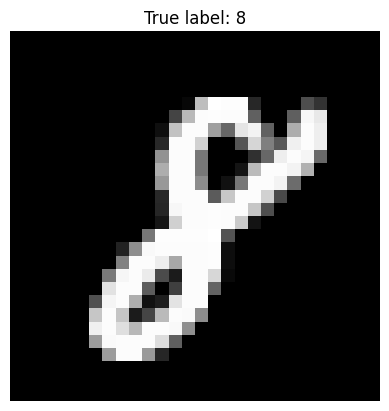

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
Predicted label: 8 with confidence 1.0000


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

def create_model():
    model = Sequential([
        tf.keras.Input(shape=(28, 28)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = create_model()
model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test)
)
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Test accuracy before saving: {accuracy:.4f}, loss: {loss:.4f}')

model.save('mnist_model.h5')
print("Model saved to 'mnist_model.h5'")

loaded_model = load_model('mnist_model.h5')
print("Model loaded from 'mnist_model.h5'")

loaded_loss, loaded_accuracy = loaded_model.evaluate(x_test, y_test)
print(f'Test accuracy after loading: {loaded_accuracy:.4f}, loss: {loaded_loss:.4f}')

idx = np.random.randint(0, x_test.shape[0])
random_img = x_test[idx]
true_label = np.argmax(y_test[idx])

plt.imshow(random_img, cmap='gray')
plt.title(f"True label: {true_label}")
plt.axis('off')
plt.show()

img_input = random_img.reshape(1, 28, 28)
prediction = loaded_model.predict(img_input)
predicted_label = np.argmax(prediction)
confidence = np.max(prediction)
print(f"Predicted label: {predicted_label} with confidence {confidence:.4f}")
